# EnergySense AI: Smart Electricity Consumption Analysis & Forecasting

## Project Overview
This project analyzes household electricity consumption data using Python and Machine Learning.

The goal is to:
- Analyze electricity usage patterns
- Identify peak consumption hours
- Compare weekday and weekend usage
- Predict electricity consumption
- Detect unusual energy usage behavior

In [79]:
import pandas as pd
import numpy as np

# Data visualization library
import matplotlib.pyplot as plt

# Machine learning libraries
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error, r2_score

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [80]:
!pip install ucimlrepo

In [81]:
from ucimlrepo import fetch_ucirepo

# Download the Individual Household Electric Power Consumption dataset
dataset = fetch_ucirepo(id=235)

# Get the data
df = dataset.data.features.copy()

print("Dataset downloaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset downloaded successfully!
Dataset shape: (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [82]:
# Check missing values before cleaning
df.isnull().sum()

Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64

In [83]:
# Combine Date and Time into one datetime column
df["datetime"]=pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

# Convert measurement columns to numeric values
numeric_columns =[
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove rows with missing or invalid values
df = df.dropna()

print("New dataset shape:", df.shape)

df.head()

New dataset shape: (2049280, 10)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [84]:
#Create time-based features
df["date"]= df["datetime"].dt.date
df["hour"]= df["datetime"].dt.hour
df["day_of_week"]= df["datetime"].dt.dayofweek
df["month"]= df["datetime"].dt.month
df["year"]= df["datetime"].dt.year

df["is_weekend"]= df["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime,date,hour,day_of_week,month,year,is_weekend
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,2006-12-16,17,5,12,2006,1
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,2006-12-16,17,5,12,2006,1
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00,2006-12-16,17,5,12,2006,1
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00,2006-12-16,17,5,12,2006,1
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00,2006-12-16,17,5,12,2006,1


In [85]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime,hour,day_of_week,month,year,is_weekend
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2049280,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00,2008-12-02 00:59:44.397740544,1.150391e+01,2.989276e+00,6.454433e+00,2.008425e+03,2.824660e-01
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,2006-12-16 17:24:00,0.000000e+00,0.000000e+00,1.000000e+00,2.006000e+03,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2007-12-10 05:37:45,5.000000e+00,1.000000e+00,3.000000e+00,2.007000e+03,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2008-11-30 01:22:30,1.200000e+01,3.000000e+00,6.000000e+00,2.008000e+03,0.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01,2009-11-23 20:31:15,1.800000e+01,5.000000e+00,9.000000e+00,2.009000e+03,1.000000e+00
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01,2010-11-26 21:02:00,2.300000e+01,6.000000e+00,1.200000e+01,2.010000e+03,1.000000e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00,NaN,6.925189e+00,1.997633e+00,3.423209e+00,1.124388e+00,4.501989e-01


# The data has been cleaned

In [86]:
df.isnull().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
datetime                 0
date                     0
hour                     0
day_of_week              0
month                    0
year                     0
is_weekend               0
dtype: int64

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2049280 entries, 0 to 2075258
Data columns (total 16 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   object        
 1   Time                   object        
 2   Global_active_power    float64       
 3   Global_reactive_power  float64       
 4   Voltage                float64       
 5   Global_intensity       float64       
 6   Sub_metering_1         float64       
 7   Sub_metering_2         float64       
 8   Sub_metering_3         float64       
 9   datetime               datetime64[ns]
 10  date                   object        
 11  hour                   int32         
 12  day_of_week            int32         
 13  month                  int32         
 14  year                   int32         
 15  is_weekend             int64         
dtypes: datetime64[ns](1), float64(7), int32(4), int64(1), object(3)
memory usage: 234.5+ MB


## Daily Electricity Consumption Trend

In this section, we analyze the total electricity consumption for each day.

This helps us understand how energy usage changes over time and identify high-consumption and low-consumption days.

In [88]:
# Calculate total daily energy consumption in kWh
daily_energy_kwh = df.groupby("date")["Global_active_power"].sum() / 60

# Display first 5 days
daily_energy_kwh.head()

date
2006-12-16    20.152933
2006-12-17    56.507667
2006-12-18    36.730433
2006-12-19    27.769900
2006-12-20    37.095800
Name: Global_active_power, dtype: float64

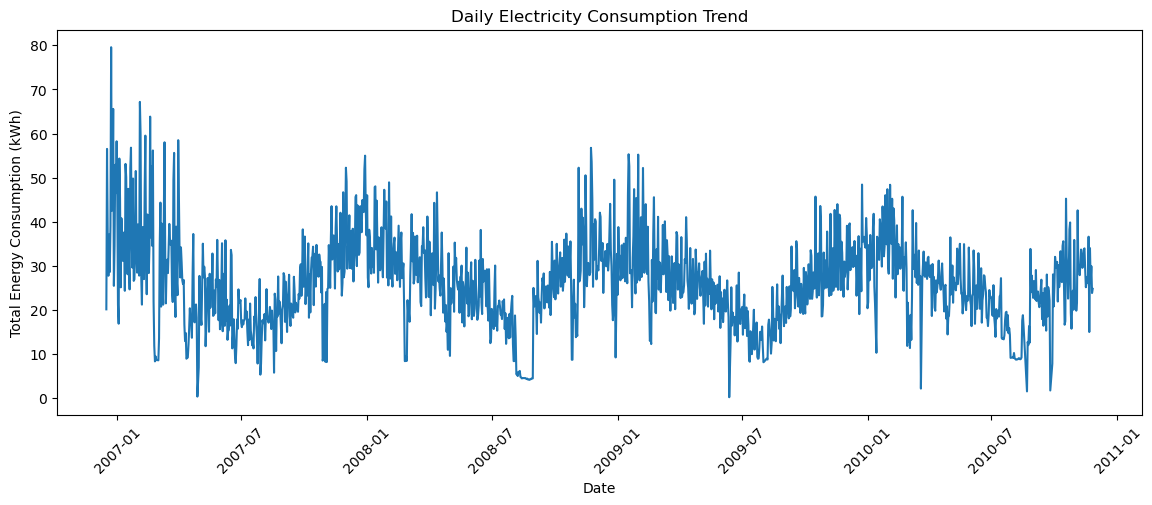

In [89]:
plt.figure(figsize=(14, 5))

plt.plot(daily_energy_kwh.index, daily_energy_kwh.values)

plt.title("Daily Electricity Consumption Trend")
plt.xlabel("Date")
plt.ylabel("Total Energy Consumption (kWh)")
plt.xticks(rotation=45)

plt.show()

In [90]:
highest_day = daily_energy_kwh.idxmax()
highest_value = daily_energy_kwh.max()

lowest_day = daily_energy_kwh.idxmin()
lowest_value = daily_energy_kwh.min()

print("Highest consumption day:", highest_day)
print("Highest daily energy consumption:", round(highest_value, 2), "kWh")

print("Lowest consumption day:", lowest_day)
print("Lowest daily energy consumption:", round(lowest_value, 2), "kWh")

Highest consumption day: 2006-12-23
Highest daily energy consumption: 79.56 kWh
Lowest consumption day: 2009-06-13
Lowest daily energy consumption: 0.24 kWh


### Daily Consumption Insight

The daily electricity consumption chart shows noticeable changes in energy usage over time.

Some days have much higher consumption than others, which may be related to changes in household activity, seasonal behavior, or the use of high-power appliances.

The highest and lowest consumption days help identify unusual or important usage patterns that can support energy monitoring and planning.

## Peak Hours Analysis

In this section, we analyze the average electricity consumption for each hour of the day.

This helps identify peak usage hours, which are important for electricity demand planning and energy management.

In [91]:
# Calculate average electricity consumption for each hour
hourly_average = df.groupby("hour")["Global_active_power"].mean()

# Display hourly average values
hourly_average

hour
0     0.659434
1     0.539325
2     0.480621
3     0.444866
4     0.443847
5     0.453674
6     0.791600
7     1.502246
8     1.461016
9     1.331645
10    1.260627
11    1.245822
12    1.207075
13    1.144532
14    1.082839
15    0.990760
16    0.948905
17    1.055109
18    1.326451
19    1.733335
20    1.899064
21    1.877697
22    1.412615
23    0.902142
Name: Global_active_power, dtype: float64

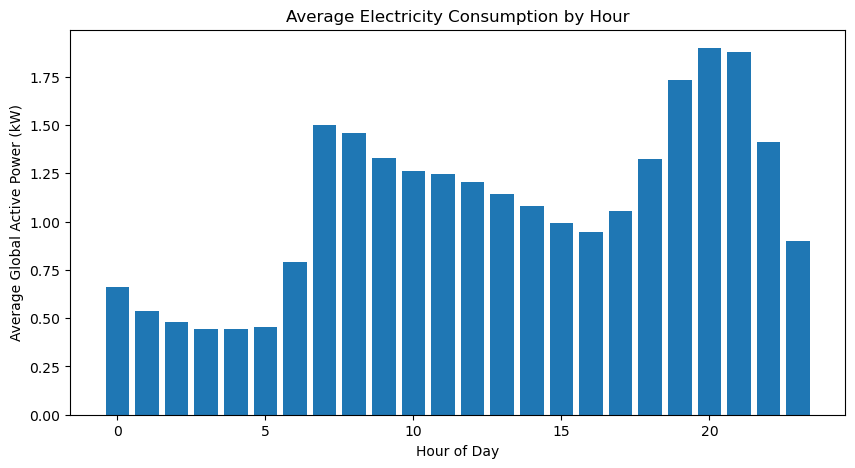

In [92]:
plt.figure(figsize=(10, 5))

plt.bar(hourly_average.index, hourly_average.values)

plt.title("Average Electricity Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Global Active Power (kW)")

plt.show()

In [93]:
peak_hour = hourly_average.idxmax()
peak_value = hourly_average.max()

lowest_hour = hourly_average.idxmin()
lowest_value = hourly_average.min()

print("Peak consumption hour:", peak_hour)
print("Highest average power:", round(peak_value, 3), "kW")

print("Lowest consumption hour:", lowest_hour)
print("Lowest average power:", round(lowest_value, 3), "kW")

Peak consumption hour: 20
Highest average power: 1.899 kW
Lowest consumption hour: 4
Lowest average power: 0.444 kW


### Peak Hours Insight

The analysis shows that the highest average electricity consumption occurs at 8:00 PM, while the lowest average consumption occurs at 4:00 AM.

This pattern suggests that electricity usage increases during evening hours, likely due to higher household activity and the use of appliances.

Identifying peak hours is important for energy planning, demand forecasting, and reducing pressure on the electricity network.

## Weekday vs Weekend Consumption

In this section, we compare average electricity consumption between weekdays and weekends.

This helps us understand whether household energy usage changes during weekends compared to normal weekdays.

In [94]:
# Compare average electricity consumption between weekdays and weekends
weekend_comparison = df.groupby("is_weekend")["Global_active_power"].mean()

# Rename index values for better readability
weekend_comparison.index = ["Weekday", "Weekend"]

weekend_comparison

Weekday    1.035472
Weekend    1.234232
Name: Global_active_power, dtype: float64

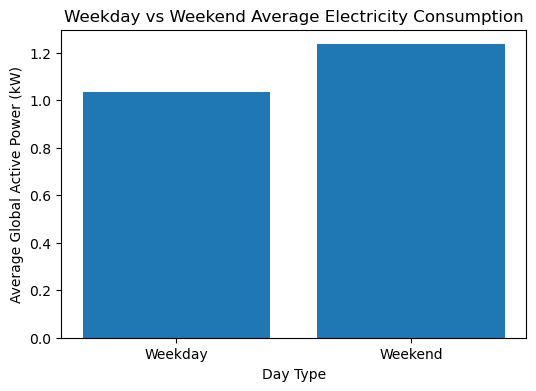

In [95]:
plt.figure(figsize=(6, 4))

plt.bar(weekend_comparison.index, weekend_comparison.values)

plt.title("Weekday vs Weekend Average Electricity Consumption")
plt.xlabel("Day Type")
plt.ylabel("Average Global Active Power (kW)")

plt.show()

In [96]:
weekday_value = weekend_comparison["Weekday"]
weekend_value = weekend_comparison["Weekend"]

print("Weekday average consumption:", round(weekday_value, 3), "kW")
print("Weekend average consumption:", round(weekend_value, 3), "kW")

difference = weekend_value - weekday_value
print("Difference:", round(difference, 3), "kW")

Weekday average consumption: 1.035 kW
Weekend average consumption: 1.234 kW
Difference: 0.199 kW


### Weekday vs Weekend Insight

The analysis shows that average electricity consumption is higher during weekends compared to weekdays.

Weekday average consumption is 1.035 kW, while weekend average consumption is 1.234 kW.

This suggests that household activity increases during weekends, which leads to higher electricity usage. This information can support better energy demand forecasting and planning.

## Sub-Metering Analysis

In this section, we analyze electricity consumption across different household sub-metering areas.

The dataset includes three sub-metering columns:
- Sub_metering_1: Kitchen area
- Sub_metering_2: Laundry room
- Sub_metering_3: Water heater and air conditioner

This analysis helps identify which area consumes the most energy.

In [97]:
# Calculate total energy usage for each sub-metering area
sub_metering_totals = df[
    ["Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]
].sum()

sub_metering_totals

Sub_metering_1     2299135.0
Sub_metering_2     2661031.0
Sub_metering_3    13235167.0
dtype: float64

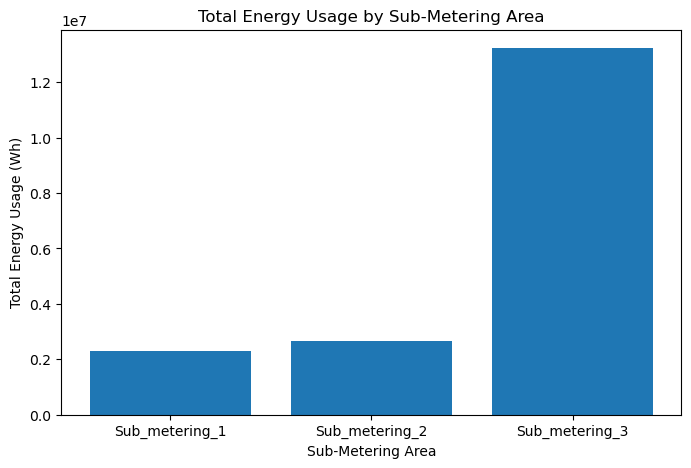

In [98]:
plt.figure(figsize=(8, 5))

plt.bar(sub_metering_totals.index, sub_metering_totals.values)

plt.title("Total Energy Usage by Sub-Metering Area")
plt.xlabel("Sub-Metering Area")
plt.ylabel("Total Energy Usage (Wh)")

plt.show()

In [99]:
highest_sub_metering = sub_metering_totals.idxmax()
highest_sub_metering_value = sub_metering_totals.max()

print("Highest energy-consuming area:", highest_sub_metering)
print("Total energy usage:", round(highest_sub_metering_value, 2), "Wh")

Highest energy-consuming area: Sub_metering_3
Total energy usage: 13235167.0 Wh


### Sub-Metering Insight

The analysis shows that Sub_metering_3 has the highest total energy consumption compared to Sub_metering_1 and Sub_metering_2.

This indicates that the water heater and air conditioner consume significantly more energy than the kitchen and laundry room areas.

This insight can help users focus on high-consumption appliances to improve energy efficiency and reduce electricity costs.

## Other Household Energy Consumption

The dataset provides three sub-metering columns, but the total household energy consumption may include other appliances as well.

In this section, we calculate the energy consumed by other household equipment that is not included in the three sub-metering areas.

In [100]:
# Calculate energy consumed by other household equipment
df["other_energy_wh"] = (
    df["Global_active_power"] * 1000 / 60
    - df["Sub_metering_1"]
    - df["Sub_metering_2"]
    - df["Sub_metering_3"]
)

df[["Global_active_power", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3", "other_energy_wh"]].head()

,Global_active_power,Sub_metering_1,Sub_metering_2,Sub_metering_3,other_energy_wh
0,4.216,0.0,1.0,17.0,52.266667
1,5.360,0.0,1.0,16.0,72.333333
2,5.374,0.0,2.0,17.0,70.566667
3,5.388,0.0,1.0,17.0,71.800000
4,3.666,0.0,1.0,17.0,43.100000


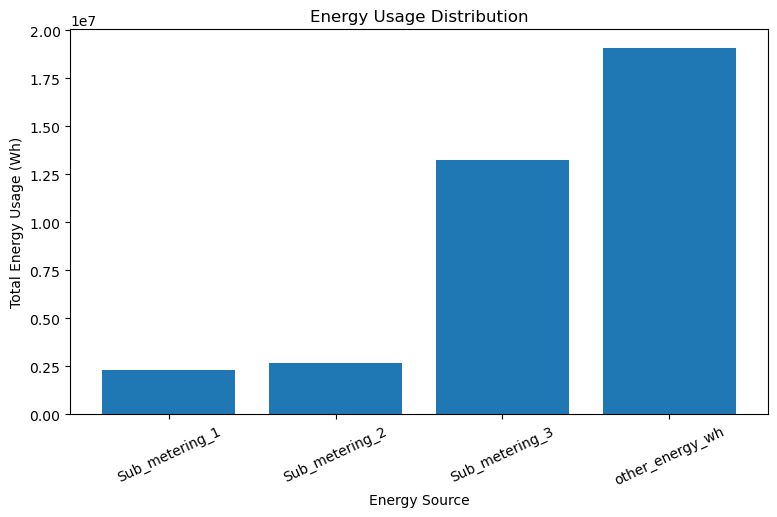

Sub_metering_1      2299135.0
Sub_metering_2      2661031.0
Sub_metering_3     13235167.0
other_energy_wh    19088414.7
dtype: float64

In [101]:
# Compare all energy sources including other household equipment
energy_sources = df[
    ["Sub_metering_1", "Sub_metering_2", "Sub_metering_3", "other_energy_wh"]
].sum()

plt.figure(figsize=(9, 5))

plt.bar(energy_sources.index, energy_sources.values)

plt.title("Energy Usage Distribution")
plt.xlabel("Energy Source")
plt.ylabel("Total Energy Usage (Wh)")
plt.xticks(rotation=25)

plt.show()

energy_sources

In [102]:
highest_energy_source = energy_sources.idxmax()
highest_energy_value = energy_sources.max()

print("Highest energy source:", highest_energy_source)
print("Total energy usage:", round(highest_energy_value, 2), "Wh")

Highest energy source: other_energy_wh
Total energy usage: 19088414.7 Wh


### Other Energy Consumption Insight

The analysis shows that `other_energy_wh` has the highest total energy consumption compared to the three sub-metering areas.

This means that a large part of household electricity usage comes from appliances or equipment not directly included in the three sub-metering categories.

This insight highlights the importance of monitoring total household consumption, not only specific measured areas.

## Machine Learning Forecasting Model

In this section, we build a machine learning model to forecast hourly electricity consumption.

Instead of predicting consumption only from current electrical measurements, we create time-based and historical features such as previous hour consumption and previous day consumption.

This makes the model more useful for energy forecasting and demand planning.

In [103]:
# Create hourly energy consumption data in kWh
hourly_data = df.set_index("datetime").resample("h")["Global_active_power"].sum() / 60

# Convert Series to DataFrame
hourly_data = hourly_data.to_frame(name="energy_kwh")

# Remove missing values
hourly_data = hourly_data.dropna()

hourly_data.head()

,energy_kwh
datetime,
2006-12-16 17:00:00,2.533733
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


In [104]:
# Create time-based features
hourly_data["hour"] = hourly_data.index.hour
hourly_data["day_of_week"] = hourly_data.index.dayofweek
hourly_data["month"] = hourly_data.index.month
hourly_data["is_weekend"] = hourly_data["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)

# Create historical consumption features
hourly_data["previous_hour_energy"] = hourly_data["energy_kwh"].shift(1)
hourly_data["previous_day_same_hour_energy"] = hourly_data["energy_kwh"].shift(24)
hourly_data["rolling_24h_average"] = hourly_data["energy_kwh"].rolling(window=24).mean()

# Remove missing values created by shifting and rolling
hourly_data = hourly_data.dropna()

hourly_data.head()

,energy_kwh,hour,day_of_week,month,is_weekend,previous_hour_energy,previous_day_same_hour_energy,rolling_24h_average
datetime,,,,,,,,
2006-12-17 17:00:00,3.406767,17,6,12,1,3.326033,2.533733,2.465140
2006-12-17 18:00:00,3.697100,18,6,12,1,3.406767,3.632200,2.467844
2006-12-17 19:00:00,2.908400,19,6,12,1,3.697100,3.400233,2.447351
2006-12-17 20:00:00,3.361500,20,6,12,1,2.908400,3.268567,2.451224
2006-12-17 21:00:00,3.040767,21,6,12,1,3.361500,3.056467,2.450569


In [105]:
print("Hourly dataset shape:", hourly_data.shape)

hourly_data.head()

Hourly dataset shape: (34565, 8)


,energy_kwh,hour,day_of_week,month,is_weekend,previous_hour_energy,previous_day_same_hour_energy,rolling_24h_average
datetime,,,,,,,,
2006-12-17 17:00:00,3.406767,17,6,12,1,3.326033,2.533733,2.465140
2006-12-17 18:00:00,3.697100,18,6,12,1,3.406767,3.632200,2.467844
2006-12-17 19:00:00,2.908400,19,6,12,1,3.697100,3.400233,2.447351
2006-12-17 20:00:00,3.361500,20,6,12,1,2.908400,3.268567,2.451224
2006-12-17 21:00:00,3.040767,21,6,12,1,3.361500,3.056467,2.450569


In [106]:
features = [
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "previous_hour_energy",
    "previous_day_same_hour_energy",
    "rolling_24h_average"
]

target = "energy_kwh"

X = hourly_data[features]
y = hourly_data[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (34565, 7)
Target shape: (34565,)


In [107]:
split_index = int(len(hourly_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (27652, 7)
Testing data: (6913, 7)


In [108]:
forecast_model = LinearRegression()

forecast_model.fit(X_train, y_train)

print("Forecasting model trained successfully!")

Forecasting model trained successfully!


In [109]:
forecast_predictions = forecast_model.predict(X_test)

mae = mean_absolute_error(y_test, forecast_predictions)
r2 = r2_score(y_test, forecast_predictions)

print("Mean Absolute Error:", round(mae, 4), "kWh")
print("R2 Score:", round(r2, 4))

Mean Absolute Error: 0.3672 kWh
R2 Score: 0.5159


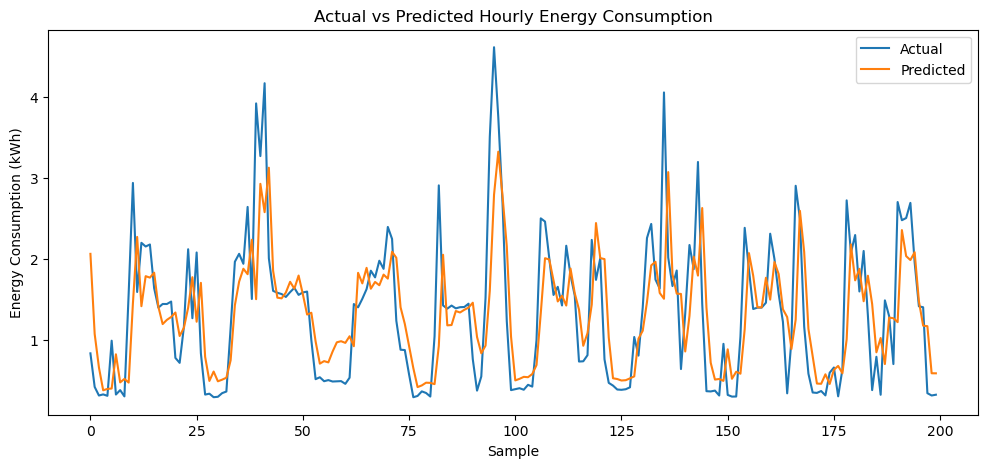

In [110]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:200],
    "Predicted": forecast_predictions[:200]
})

plt.figure(figsize=(12, 5))

plt.plot(comparison["Actual"].values, label="Actual")
plt.plot(comparison["Predicted"].values, label="Predicted")

plt.title("Actual vs Predicted Hourly Energy Consumption")
plt.xlabel("Sample")
plt.ylabel("Energy Consumption (kWh)")
plt.legend()

plt.show()

In [111]:
new_hour = pd.DataFrame({
    "hour": [20],
    "day_of_week": [5],
    "month": [12],
    "is_weekend": [1],
    "previous_hour_energy": [1.8],
    "previous_day_same_hour_energy": [2.1],
    "rolling_24h_average": [1.5]
})

predicted_energy = forecast_model.predict(new_hour)

print("Predicted hourly energy consumption:", round(predicted_energy[0], 3), "kWh")

Predicted hourly energy consumption: 1.853 kWh


In [112]:
# Recreate hourly energy consumption data in kWh
hourly_data = df.set_index("datetime").resample("h")["Global_active_power"].sum() / 60

# Convert Series to DataFrame
hourly_data = hourly_data.to_frame(name="energy_kwh")

# Remove missing values
hourly_data = hourly_data.dropna()

# Create time-based features
hourly_data["hour"] = hourly_data.index.hour
hourly_data["day_of_week"] = hourly_data.index.dayofweek
hourly_data["month"] = hourly_data.index.month
hourly_data["is_weekend"] = hourly_data["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)

# Create historical consumption features
hourly_data["previous_hour_energy"] = hourly_data["energy_kwh"].shift(1)
hourly_data["previous_day_same_hour_energy"] = hourly_data["energy_kwh"].shift(24)
hourly_data["rolling_24h_average"] = hourly_data["energy_kwh"].rolling(window=24).mean()

# Remove missing values created by shift and rolling
hourly_data = hourly_data.dropna()

print("Hourly data prepared successfully!")
print(hourly_data.shape)

hourly_data.head()

Hourly data prepared successfully!
(34565, 8)


,energy_kwh,hour,day_of_week,month,is_weekend,previous_hour_energy,previous_day_same_hour_energy,rolling_24h_average
datetime,,,,,,,,
2006-12-17 17:00:00,3.406767,17,6,12,1,3.326033,2.533733,2.465140
2006-12-17 18:00:00,3.697100,18,6,12,1,3.406767,3.632200,2.467844
2006-12-17 19:00:00,2.908400,19,6,12,1,3.697100,3.400233,2.447351
2006-12-17 20:00:00,3.361500,20,6,12,1,2.908400,3.268567,2.451224
2006-12-17 21:00:00,3.040767,21,6,12,1,3.361500,3.056467,2.450569


### Forecasting Model Insight

The forecasting model achieved a Mean Absolute Error of 0.3672 kWh and an R2 Score of 0.5159.

This means that the model can capture part of the electricity consumption pattern using time-based and historical features such as previous hour consumption, previous day consumption, and rolling 24-hour average.

Although the model performance is moderate, it shows that historical energy behavior can help forecast future electricity demand. The model can be improved in the future by using more advanced algorithms and adding external features such as weather and temperature.

## Anomaly Detection

In this section, we detect unusual hourly electricity consumption patterns.

Anomaly detection can help identify unexpected energy usage, possible equipment problems, abnormal household behavior, or unusual demand patterns.

In [113]:
# Prepare data for anomaly detection
anomaly_data = hourly_data[
    [
        "energy_kwh",
        "previous_hour_energy",
        "previous_day_same_hour_energy",
        "rolling_24h_average"
    ]
].copy()

anomaly_data.head()

,energy_kwh,previous_hour_energy,previous_day_same_hour_energy,rolling_24h_average
datetime,,,,
2006-12-17 17:00:00,3.406767,3.326033,2.533733,2.465140
2006-12-17 18:00:00,3.697100,3.406767,3.632200,2.467844
2006-12-17 19:00:00,2.908400,3.697100,3.400233,2.447351
2006-12-17 20:00:00,3.361500,2.908400,3.268567,2.451224
2006-12-17 21:00:00,3.040767,3.361500,3.056467,2.450569


In [114]:
# Train Isolation Forest model for anomaly detection
anomaly_model = IsolationForest(
    contamination=0.02,
    random_state=42
)

anomaly_data["anomaly"] = anomaly_model.fit_predict(anomaly_data)

# -1 means anomaly, 1 means normal
anomalies = anomaly_data[anomaly_data["anomaly"] == -1]

print("Total records:", len(anomaly_data))
print("Number of anomalies detected:", len(anomalies))

anomalies.head()

Total records: 34565
Number of anomalies detected: 692


,energy_kwh,previous_hour_energy,previous_day_same_hour_energy,rolling_24h_average,anomaly
datetime,,,,,
2006-12-17 17:00:00,3.406767,3.326033,2.533733,2.465140,-1
2006-12-17 18:00:00,3.697100,3.406767,3.632200,2.467844,-1
2006-12-17 19:00:00,2.908400,3.697100,3.400233,2.447351,-1
2006-12-17 20:00:00,3.361500,2.908400,3.268567,2.451224,-1
2006-12-17 21:00:00,3.040767,3.361500,3.056467,2.450569,-1


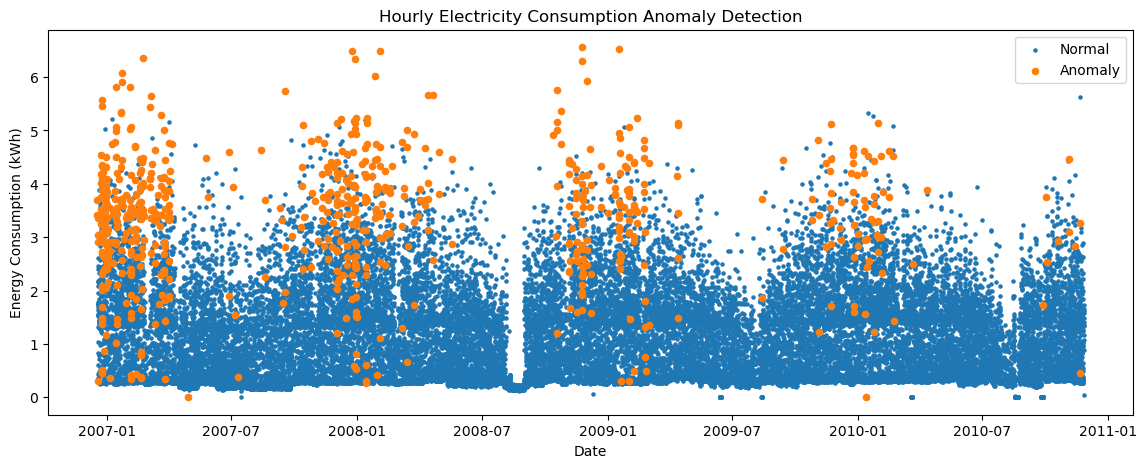

In [115]:
plt.figure(figsize=(14, 5))

plt.scatter(
    anomaly_data.index,
    anomaly_data["energy_kwh"],
    s=5,
    label="Normal"
)

plt.scatter(
    anomalies.index,
    anomalies["energy_kwh"],
    s=20,
    label="Anomaly"
)

plt.title("Hourly Electricity Consumption Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (kWh)")
plt.legend()

plt.show()

### Anomaly Detection Insight

The Isolation Forest model detected 692 anomalous hourly consumption records out of 34,565 total hourly records.

These anomalies represent unusual electricity consumption patterns that differ from normal household usage.

Such anomalies may indicate abnormal demand, unusual appliance behavior, equipment issues, or sudden changes in household activity.

Anomaly detection can support energy monitoring systems by helping identify unusual consumption early.

## Business Recommendations

Based on the analysis, the following recommendations can be made:

1. Monitor evening peak hours, especially around 8:00 PM, because this period shows the highest average electricity consumption.

2. Improve weekend energy planning because the analysis shows that weekend consumption is higher than weekday consumption.

3. Focus on high-consumption appliances such as water heaters and air conditioners, since Sub_metering_3 showed the highest measured energy usage.

4. Monitor other household energy consumption because `other_energy_wh` represented the highest overall energy usage source.

5. Use forecasting models to estimate future electricity demand and support better energy planning.

6. Use anomaly detection to identify unusual electricity consumption patterns that may indicate abnormal usage or equipment problems.

In [116]:
# Save a clean sample of the processed dataset
clean_sample = df.sample(n=10000, random_state=42)

clean_sample.to_csv("clean_energy_sample.csv", index=False)

print("Clean sample saved successfully!")

Clean sample saved successfully!


In [117]:
# Save the hourly forecasting dataset
hourly_data.to_csv("hourly_energy_forecasting_data.csv")

print("Hourly forecasting dataset saved successfully!")

Hourly forecasting dataset saved successfully!
